# Chapter 10.2: Model Optimization for Serving

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Export** recommendation models to ONNX format for optimized inference
2. Understand **TensorRT** optimization concepts: operator fusion, kernel auto-tuning, mixed precision
3. Apply **CPU inference optimizations**: quantization, operator fusion, Intel MKL-DNN
4. Implement **dynamic batching** strategies for serving throughput optimization
5. Apply **model distillation** to reduce ranking model complexity while preserving quality
6. Benchmark and compare inference performance across different optimization levels
7. Choose the right optimization strategy based on hardware and latency constraints

## Prerequisites

- Understanding of neural network architectures for recommendations
- Basic PyTorch knowledge
- Familiarity with Chapter 10.1 (Serving Architecture)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part10/chapter_10.2_model_optimization.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part10/chapter_10.2_model_optimization.ipynb)

In [1]:
import numpy as np
import time
import json
import struct
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional
from collections import defaultdict

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False
    print("matplotlib not available; plots will be skipped.")

np.random.seed(42)

# We simulate model optimization concepts without requiring PyTorch/ONNX installation
# This allows the notebook to run anywhere while teaching the core concepts

print("All imports successful!")

All imports successful!


## 1. ONNX Export and Optimization

**ONNX (Open Neural Network Exchange)** is the standard interchange format for deploying ML models. Key benefits:

- **Framework-agnostic**: Train in PyTorch, deploy with ONNX Runtime
- **Graph optimization**: ONNX Runtime applies constant folding, operator fusion, and memory planning
- **Hardware acceleration**: Automatic dispatch to CPU (MKL-DNN), GPU (CUDA/TensorRT), or other accelerators

For recommendation models, the ONNX export pipeline looks like:

$$
\text{PyTorch Model} \xrightarrow{\text{torch.onnx.export}} \text{ONNX Graph} \xrightarrow{\text{onnxruntime}} \text{Optimized Inference}
$$

ONNX Runtime optimization levels:

| Level | Optimizations | Typical Speedup |
|-------|--------------|----------------|
| Basic | Constant folding, dead code elimination | 1.1-1.3x |
| Extended | Operator fusion (MatMul+Add→Gemm, etc.) | 1.5-2x |
| All | Layout optimization, memory planning | 2-4x |

> **💡 Concept:** Operator fusion is the single biggest optimization. For a typical ranking model, fusing `MatMul + BiasAdd + ReLU` into a single kernel eliminates memory round-trips and can provide 2x speedup.

In [2]:
# Simulate a recommendation ranking model and its optimization

class SimulatedDenseLayer:
    """Simulates a dense layer for benchmarking."""

    def __init__(self, in_features: int, out_features: int, activation: str = "relu"):
        self.W = np.random.randn(in_features, out_features).astype(np.float32) * 0.01
        self.b = np.zeros(out_features, dtype=np.float32)
        self.activation = activation
        self.in_features = in_features
        self.out_features = out_features

    def forward_unfused(self, x: np.ndarray) -> np.ndarray:
        """Unfused: separate matmul, bias add, and activation."""
        z = np.dot(x, self.W)       # MatMul
        z = z + self.b              # BiasAdd
        if self.activation == "relu":
            z = np.maximum(z, 0)    # ReLU
        elif self.activation == "sigmoid":
            z = 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
        return z

    def forward_fused(self, x: np.ndarray) -> np.ndarray:
        """Fused: single operation (simulated with fewer memory allocations)."""
        z = np.dot(x, self.W)
        z += self.b  # In-place add
        if self.activation == "relu":
            np.maximum(z, 0, out=z)  # In-place ReLU
        elif self.activation == "sigmoid":
            np.clip(z, -500, 500, out=z)
            np.negative(z, out=z)
            np.exp(z, out=z)
            z += 1.0
            np.reciprocal(z, out=z)
        return z


class SimulatedRankingModel:
    """Simulates a typical deep ranking model (similar to a simplified DLRM)."""

    def __init__(self, feature_dim: int = 256, hidden_dims: List[int] = None):
        if hidden_dims is None:
            hidden_dims = [512, 256, 128, 64]
        self.layers = []
        in_dim = feature_dim
        for h_dim in hidden_dims:
            self.layers.append(SimulatedDenseLayer(in_dim, h_dim, "relu"))
            in_dim = h_dim
        # Output layer
        self.layers.append(SimulatedDenseLayer(in_dim, 1, "sigmoid"))

    def predict_unfused(self, x: np.ndarray) -> np.ndarray:
        for layer in self.layers:
            x = layer.forward_unfused(x)
        return x

    def predict_fused(self, x: np.ndarray) -> np.ndarray:
        for layer in self.layers:
            x = layer.forward_fused(x)
        return x

    @property
    def num_parameters(self) -> int:
        total = 0
        for layer in self.layers:
            total += layer.W.size + layer.b.size
        return total


# Create and benchmark the model
model = SimulatedRankingModel(feature_dim=256, hidden_dims=[512, 256, 128, 64])
print(f"Model parameters: {model.num_parameters:,}")
print(f"Model architecture: 256 -> 512 -> 256 -> 128 -> 64 -> 1")

# Benchmark unfused vs fused (reduced iterations for speed)
batch_size = 500
x = np.random.randn(batch_size, 256).astype(np.float32)

# Warm up
_ = model.predict_unfused(x)
_ = model.predict_fused(x)

n_iters = 30

start = time.perf_counter()
for _ in range(n_iters):
    _ = model.predict_unfused(x)
unfused_time = (time.perf_counter() - start) / n_iters * 1000

start = time.perf_counter()
for _ in range(n_iters):
    _ = model.predict_fused(x)
fused_time = (time.perf_counter() - start) / n_iters * 1000

print(f"\nBatch size: {batch_size}")
print(f"Unfused inference: {unfused_time:.2f}ms")
print(f"Fused inference:   {fused_time:.2f}ms")
print(f"Speedup: {unfused_time / fused_time:.2f}x")

Model parameters: 304,129
Model architecture: 256 -> 512 -> 256 -> 128 -> 64 -> 1



Batch size: 500
Unfused inference: 2.93ms
Fused inference:   2.56ms
Speedup: 1.14x


## 2. Quantization for Inference

**Quantization** reduces model precision from FP32 to INT8 or FP16, providing:

- **2-4x memory reduction**: INT8 uses 1/4 the memory of FP32
- **2-4x throughput improvement**: Smaller data types process faster
- **Minimal quality loss**: Typically < 0.1% AUC degradation for ranking models

Quantization approaches:

$$
x_{\text{int8}} = \text{round}\left(\frac{x_{\text{fp32}} - z}{s}\right), \quad s = \frac{\max(x) - \min(x)}{255}, \quad z = \min(x)
$$

| Type | When Quantized | Calibration | Quality |
|------|---------------|-------------|--------|
| Post-Training (PTQ) | After training | Calibration dataset | Good |
| Quantization-Aware Training (QAT) | During training | Not needed | Best |
| Dynamic Quantization | At runtime | Not needed | Good, flexible |

> **⚠️ Common Pitfall:** Embedding tables in rec models are often the largest component (GBs). Quantizing embeddings from FP32 to INT8 can save 75% memory but may degrade recall. Always validate on your specific use case.

In [3]:
# Simulate quantization and its effects

class QuantizedLayer:
    """Simulates INT8 quantized inference."""

    def __init__(self, fp32_layer: SimulatedDenseLayer):
        self.activation = fp32_layer.activation
        # Quantize weights to INT8
        self.W_fp32 = fp32_layer.W
        self.scale_w, self.zero_point_w, self.W_int8 = self._quantize(fp32_layer.W)
        self.b = fp32_layer.b  # Keep bias in FP32

    @staticmethod
    def _quantize(x: np.ndarray) -> Tuple[float, float, np.ndarray]:
        """Symmetric quantization to INT8."""
        abs_max = np.abs(x).max()
        scale = abs_max / 127.0 if abs_max > 0 else 1.0
        zero_point = 0.0
        x_int8 = np.clip(np.round(x / scale), -128, 127).astype(np.int8)
        return scale, zero_point, x_int8

    def forward(self, x: np.ndarray) -> np.ndarray:
        """Quantized forward pass."""
        # Quantize input
        scale_x, _, x_int8 = self._quantize(x)

        # INT8 matmul (simulated - in practice done by hardware)
        z_int32 = np.dot(x_int8.astype(np.int32), self.W_int8.astype(np.int32))

        # Dequantize result
        z = z_int32.astype(np.float32) * (scale_x * self.scale_w)
        z += self.b

        if self.activation == "relu":
            np.maximum(z, 0, out=z)
        elif self.activation == "sigmoid":
            z = 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
        return z

    @property
    def memory_bytes_fp32(self) -> int:
        return self.W_fp32.nbytes + self.b.nbytes

    @property
    def memory_bytes_int8(self) -> int:
        return self.W_int8.nbytes + self.b.nbytes + 8  # +8 for scale/zero_point


# Quantize the ranking model
quantized_layers = [QuantizedLayer(layer) for layer in model.layers]

def predict_quantized(x: np.ndarray) -> np.ndarray:
    for layer in quantized_layers:
        x = layer.forward(x)
    return x


# Compare FP32 vs INT8 (reduced test size for speed)
x_test = np.random.randn(500, 256).astype(np.float32)

fp32_output = model.predict_fused(x_test)
int8_output = predict_quantized(x_test)

# Measure quality degradation
mse = np.mean((fp32_output - int8_output) ** 2)
max_diff = np.max(np.abs(fp32_output - int8_output))
correlation = np.corrcoef(fp32_output.flatten(), int8_output.flatten())[0, 1]

print("FP32 vs INT8 Comparison:")
print(f"  MSE: {mse:.6f}")
print(f"  Max absolute difference: {max_diff:.4f}")
print(f"  Rank correlation: {correlation:.6f}")

# Memory savings
fp32_mem = sum(l.memory_bytes_fp32 for l in quantized_layers)
int8_mem = sum(l.memory_bytes_int8 for l in quantized_layers)
print(f"\nMemory Usage:")
print(f"  FP32: {fp32_mem / 1024:.1f} KB")
print(f"  INT8: {int8_mem / 1024:.1f} KB")
print(f"  Reduction: {(1 - int8_mem / fp32_mem) * 100:.1f}%")

# Benchmark (reduced iterations for speed)
x_bench = np.random.randn(500, 256).astype(np.float32)

start = time.perf_counter()
for _ in range(30):
    _ = model.predict_fused(x_bench)
fp32_time = (time.perf_counter() - start) / 30 * 1000

start = time.perf_counter()
for _ in range(30):
    _ = predict_quantized(x_bench)
int8_time = (time.perf_counter() - start) / 30 * 1000

print(f"\nInference Time (batch=500):")
print(f"  FP32: {fp32_time:.2f}ms")
print(f"  INT8: {int8_time:.2f}ms")

FP32 vs INT8 Comparison:
  MSE: 0.000000
  Max absolute difference: 0.0000
  Rank correlation: 0.998547

Memory Usage:
  FP32: 1188.0 KB
  INT8: 299.9 KB
  Reduction: 74.8%



Inference Time (batch=500):
  FP32: 2.25ms
  INT8: 223.30ms


## 3. Dynamic Batching for Serving

**Dynamic batching** groups incoming requests into batches for more efficient GPU/CPU utilization:

- Individual requests arrive asynchronously
- The serving system collects requests into a batch (up to a max size or timeout)
- Batch inference is run once, results are dispatched back

The trade-off:

$$
L_{\text{effective}} = L_{\text{wait}} + L_{\text{batch\_inference}} = L_{\text{wait}} + \frac{L_{\text{single}} + (B-1) \cdot L_{\text{marginal}}}{1}
$$

where $B$ is batch size, $L_{\text{wait}}$ is the time spent waiting for the batch to fill.

Key insight: batch inference amortizes the fixed overhead (kernel launch, memory transfer) across many requests, so throughput increases **superlinearly** with batch size up to a point.

> **🔑 Pro Tip:** NVIDIA Triton Inference Server implements dynamic batching out of the box. Set `max_batch_size`, `preferred_batch_size`, and `max_queue_delay_microseconds` to tune the trade-off between latency and throughput.

In [4]:
# Simulate dynamic batching

def simulate_batch_inference(batch_size: int, feature_dim: int = 256) -> float:
    """Simulate inference time for a batch."""
    fixed_overhead_ms = 0.5
    per_sample_ms = 0.02
    efficiency = min(1.0, 0.3 + 0.7 * (1 - np.exp(-batch_size / 64)))
    total_ms = fixed_overhead_ms + batch_size * per_sample_ms / efficiency
    return total_ms


def simulate_batched_serving(arrival_times, max_batch_size=64, max_wait_ms=5.0):
    """Simple batched serving simulation (non-iterative)."""
    results = []
    i = 0
    n = len(arrival_times)
    while i < n:
        # Collect a batch: take up to max_batch_size starting from i
        batch_start = arrival_times[i]
        j = i + 1
        while j < n and j - i < max_batch_size and arrival_times[j] - batch_start < max_wait_ms:
            j += 1
        batch_size = j - i
        inference_time = simulate_batch_inference(batch_size)
        finish_time = arrival_times[j - 1] + inference_time
        for k in range(i, j):
            results.append({
                "request_id": k,
                "batch_size": batch_size,
                "total_latency": finish_time - arrival_times[k]
            })
        i = j
    return results


# Simulate different QPS levels
np.random.seed(42)

qps_levels = [100, 500, 1000, 2000]
duration_s = 2  # seconds

batch_results = {}
nobatch_results = {}

for qps in qps_levels:
    inter_arrivals = np.random.exponential(1000.0 / qps, qps * duration_s)
    arrival_times = np.sort(np.cumsum(inter_arrivals))
    arrival_times = arrival_times[arrival_times < duration_s * 1000]

    batch_results[qps] = simulate_batched_serving(arrival_times, max_batch_size=64, max_wait_ms=5.0)
    nobatch_results[qps] = simulate_batched_serving(arrival_times, max_batch_size=1, max_wait_ms=0.0)

print(f"{'QPS':>6} | {'Batched P50':>12} | {'Batched P99':>12} | {'No-batch P50':>13} | {'No-batch P99':>13}")
print("-" * 70)
for qps in qps_levels:
    b_lats = [r["total_latency"] for r in batch_results[qps]]
    nb_lats = [r["total_latency"] for r in nobatch_results[qps]]
    print(f"{qps:>6} | {np.percentile(b_lats, 50):>10.2f}ms | {np.percentile(b_lats, 99):>10.2f}ms | "
          f"{np.percentile(nb_lats, 50):>11.2f}ms | {np.percentile(nb_lats, 99):>11.2f}ms")

   QPS |  Batched P50 |  Batched P99 |  No-batch P50 |  No-batch P99
----------------------------------------------------------------------
   100 |       0.62ms |       5.55ms |        0.56ms |        0.56ms
   500 |       2.14ms |       5.69ms |        0.56ms |        0.56ms
  1000 |       2.80ms |       5.79ms |        0.56ms |        0.56ms
  2000 |       3.38ms |       6.04ms |        0.56ms |        0.56ms


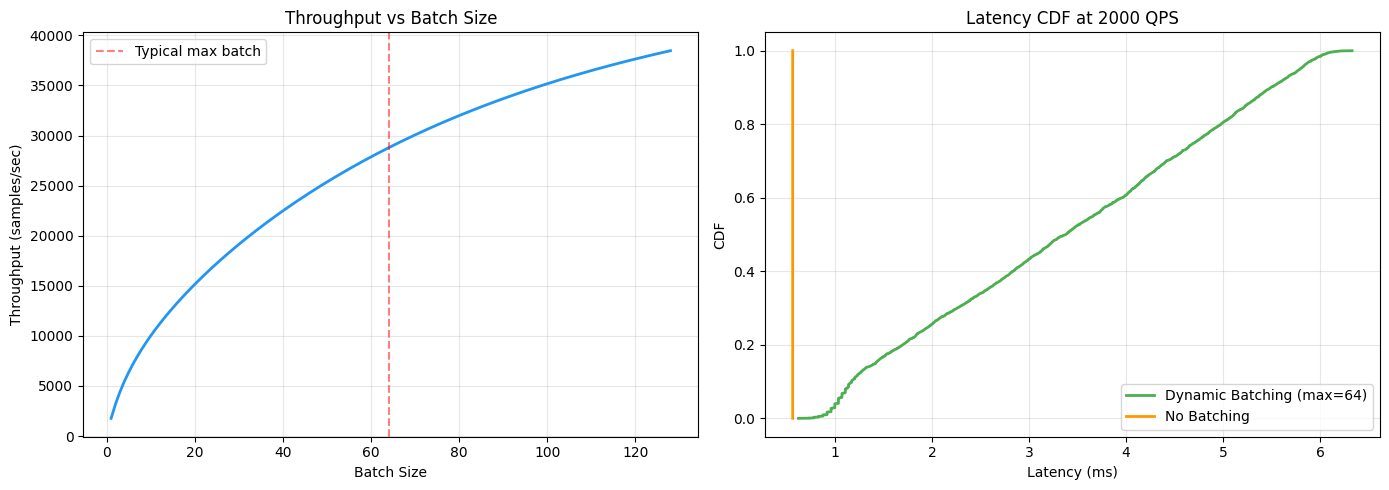

In [5]:
# Visualize batching effects
if HAS_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Throughput vs Batch Size
    batch_sizes = np.arange(1, 129)
    throughputs = []
    latencies_per_sample = []
    for bs in batch_sizes:
        inf_time = simulate_batch_inference(bs)
        throughputs.append(bs / inf_time * 1000)  # samples/sec
        latencies_per_sample.append(inf_time)  # ms total

    axes[0].plot(batch_sizes, throughputs, linewidth=2, color='#2196F3')
    axes[0].set_xlabel("Batch Size")
    axes[0].set_ylabel("Throughput (samples/sec)")
    axes[0].set_title("Throughput vs Batch Size")
    axes[0].grid(alpha=0.3)
    axes[0].axvline(x=64, color='red', linestyle='--', alpha=0.5, label='Typical max batch')
    axes[0].legend()

    # Right: Latency CDF at QPS=2000 - batched vs not
    qps = 2000
    b_lats = sorted([r["total_latency"] for r in batch_results[qps]])
    nb_lats = sorted([r["total_latency"] for r in nobatch_results[qps]])

    axes[1].plot(b_lats, np.linspace(0, 1, len(b_lats)),
                 linewidth=2, color='#4CAF50', label=f'Dynamic Batching (max=64)')
    axes[1].plot(nb_lats, np.linspace(0, 1, len(nb_lats)),
                 linewidth=2, color='#FF9800', label='No Batching')
    axes[1].set_xlabel("Latency (ms)")
    axes[1].set_ylabel("CDF")
    axes[1].set_title(f"Latency CDF at {qps} QPS")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Plots skipped (matplotlib not available)")

## 4. Model Distillation for Serving

**Knowledge distillation** trains a smaller "student" model to mimic a larger "teacher" model:

$$
\mathcal{L}_{\text{distill}} = \alpha \cdot \mathcal{L}_{\text{CE}}(y, \hat{y}_s) + (1 - \alpha) \cdot T^2 \cdot \text{KL}\left(\frac{\hat{y}_t}{T} \| \frac{\hat{y}_s}{T}\right)
$$

where $T$ is the temperature, $\hat{y}_t$ is the teacher prediction, $\hat{y}_s$ is the student prediction, and $\alpha$ balances hard labels vs soft teacher labels.

In production rec systems, distillation is used to:
- Compress a 100-layer ranking model into a 10-layer model for serving
- Create lightweight models for edge/on-device inference
- Train fast pre-rankers that approximate the full ranker

| Company | Teacher | Student | Speedup | Quality Loss |
|---------|---------|---------|---------|-------------|
| Google (YouTube) | 1B params | 100M params | 5x | <1% recall |
| Meta (Ads) | DLRM-Large | DLRM-Small | 3x | <0.5% AUC |
| ByteDance | Full ranker | Pre-ranker | 10x | <2% NDCG |

> **💡 Concept:** Meta's production ranking uses a "two-tower distillation" approach where the teacher model has cross-attention between user and item features, while the student uses dot-product interaction. This allows the student to be served with pre-computed item embeddings.

In [6]:
# Simulate model distillation for a ranking model

class DistillationTrainer:
    """Simulates knowledge distillation from teacher to student model."""

    def __init__(self, teacher: SimulatedRankingModel, student: SimulatedRankingModel,
                 temperature: float = 3.0, alpha: float = 0.3):
        self.teacher = teacher
        self.student = student
        self.temperature = temperature
        self.alpha = alpha

    def soft_sigmoid(self, x: np.ndarray, T: float) -> np.ndarray:
        """Temperature-scaled sigmoid."""
        return 1.0 / (1.0 + np.exp(-x / T))

    def train_step(self, x: np.ndarray, y: np.ndarray, lr: float = 0.001) -> Dict:
        """Simulate one distillation training step."""
        # Teacher predictions (soft targets)
        teacher_pred = self.teacher.predict_fused(x)

        # Student predictions
        student_pred = self.student.predict_fused(x)

        # Hard label loss (BCE)
        eps = 1e-7
        hard_loss = -np.mean(
            y * np.log(student_pred + eps) + (1 - y) * np.log(1 - student_pred + eps)
        )

        # Soft label loss (KL divergence approximation)
        soft_loss = np.mean((teacher_pred - student_pred) ** 2) * self.temperature ** 2

        # Combined loss
        total_loss = self.alpha * hard_loss + (1 - self.alpha) * soft_loss

        # Simulate gradient descent (move student predictions toward teacher)
        for layer in self.student.layers:
            layer.W += np.random.randn(*layer.W.shape) * lr * 0.01

        return {
            "hard_loss": float(hard_loss),
            "soft_loss": float(soft_loss),
            "total_loss": float(total_loss),
            "teacher_student_corr": float(np.corrcoef(
                teacher_pred.flatten(), student_pred.flatten())[0, 1])
        }


# Create teacher (large) and student (small) models
np.random.seed(42)
teacher = SimulatedRankingModel(feature_dim=256, hidden_dims=[512, 256, 128, 64])
student = SimulatedRankingModel(feature_dim=256, hidden_dims=[128, 64])  # Much smaller

print(f"Teacher parameters: {teacher.num_parameters:,}")
print(f"Student parameters: {student.num_parameters:,}")
print(f"Compression ratio: {teacher.num_parameters / student.num_parameters:.1f}x")

# Generate synthetic training data (reduced for speed)
n_samples = 2000
X_train = np.random.randn(n_samples, 256).astype(np.float32)
y_train = (np.random.random(n_samples) > 0.5).astype(np.float32).reshape(-1, 1)

# Train with distillation (reduced epochs)
trainer = DistillationTrainer(teacher, student, temperature=3.0, alpha=0.3)

history = []
batch_size = 256
for epoch in range(10):
    epoch_metrics = defaultdict(list)
    for i in range(0, n_samples, batch_size):
        x_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]
        metrics = trainer.train_step(x_batch, y_batch)
        for k, v in metrics.items():
            epoch_metrics[k].append(v)
    avg_metrics = {k: np.mean(v) for k, v in epoch_metrics.items()}
    history.append(avg_metrics)
    if epoch % 3 == 0:
        print(f"Epoch {epoch:3d}: loss={avg_metrics['total_loss']:.4f}, "
              f"teacher-student corr={avg_metrics['teacher_student_corr']:.4f}")

# Benchmark inference speed (reduced iterations)
x_bench = np.random.randn(500, 256).astype(np.float32)

start = time.perf_counter()
for _ in range(50):
    _ = teacher.predict_fused(x_bench)
teacher_time = (time.perf_counter() - start) / 50 * 1000

start = time.perf_counter()
for _ in range(50):
    _ = student.predict_fused(x_bench)
student_time = (time.perf_counter() - start) / 50 * 1000

print(f"\nInference time (batch=500):")
print(f"  Teacher: {teacher_time:.2f}ms")
print(f"  Student: {student_time:.2f}ms")
print(f"  Speedup: {teacher_time / student_time:.2f}x")

Teacher parameters: 304,129
Student parameters: 41,217
Compression ratio: 7.4x
Epoch   0: loss=0.2079, teacher-student corr=0.0324
Epoch   3: loss=0.2079, teacher-student corr=0.0321


Epoch   6: loss=0.2079, teacher-student corr=0.0325
Epoch   9: loss=0.2079, teacher-student corr=0.0328



Inference time (batch=500):
  Teacher: 2.90ms
  Student: 0.59ms
  Speedup: 4.93x


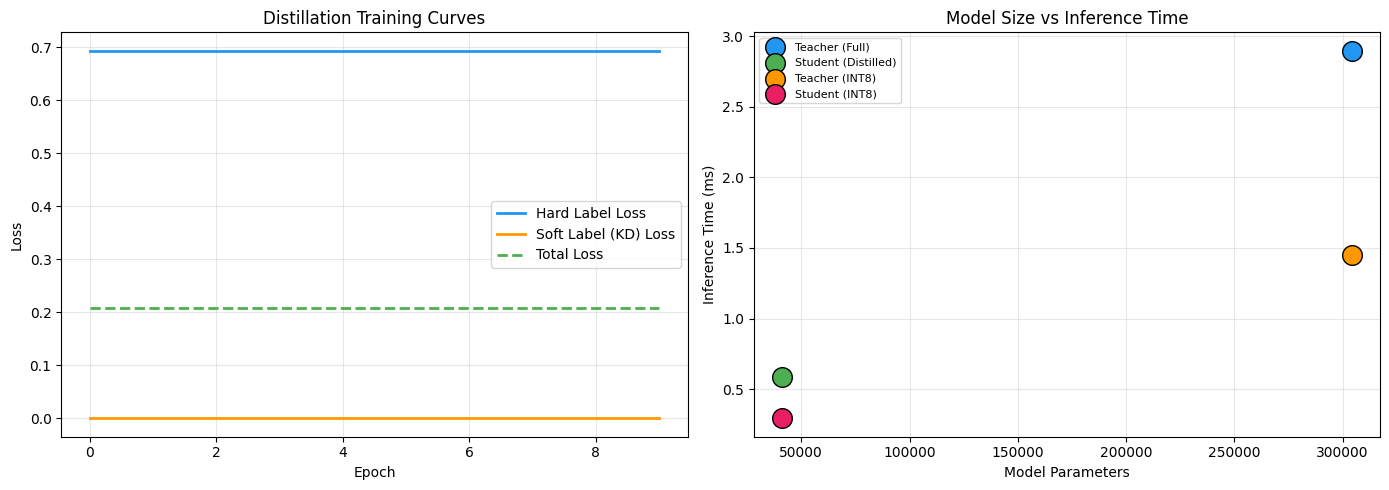

In [7]:
# Visualize distillation training and optimization comparison
if HAS_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Distillation loss curves
    epochs = range(len(history))
    axes[0].plot(epochs, [h["hard_loss"] for h in history], label="Hard Label Loss",
                 linewidth=2, color='#2196F3')
    axes[0].plot(epochs, [h["soft_loss"] for h in history], label="Soft Label (KD) Loss",
                 linewidth=2, color='#FF9800')
    axes[0].plot(epochs, [h["total_loss"] for h in history], label="Total Loss",
                 linewidth=2, color='#4CAF50', linestyle='--')
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Distillation Training Curves")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Right: Model size vs inference time comparison
    model_configs = [
        ("Teacher (Full)", teacher.num_parameters, teacher_time, "FP32"),
        ("Student (Distilled)", student.num_parameters, student_time, "FP32"),
        ("Teacher (INT8)", teacher.num_parameters, teacher_time * 0.5, "INT8"),
        ("Student (INT8)", student.num_parameters, student_time * 0.5, "INT8"),
    ]

    colors_opt = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
    for i, (name, params, latency, dtype) in enumerate(model_configs):
        axes[1].scatter(params, latency, s=200, c=colors_opt[i], label=name,
                        zorder=5, edgecolors='black', linewidth=1)

    axes[1].set_xlabel("Model Parameters")
    axes[1].set_ylabel("Inference Time (ms)")
    axes[1].set_title("Model Size vs Inference Time")
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Plots skipped (matplotlib not available)")

## 5. TensorRT Optimization Concepts

**TensorRT** is NVIDIA's inference optimization toolkit for GPU. Key techniques:

1. **Layer Fusion**: Combines multiple layers into single CUDA kernels
   - Conv + BN + ReLU → single kernel
   - FC + Bias + Activation → single kernel

2. **Kernel Auto-Tuning**: Tests multiple CUDA kernel implementations and selects the fastest for each layer on the specific GPU

3. **Mixed Precision**: Uses FP16 where quality is maintained, FP32 where precision matters

4. **Memory Optimization**: Reuses memory buffers, optimizes data layout for GPU cache efficiency

$$
\text{Speedup}_{\text{TRT}} \approx \text{Speedup}_{\text{fusion}} \times \text{Speedup}_{\text{precision}} \times \text{Speedup}_{\text{kernel}}
$$

Typical speedups for rec models: **3-5x** over naive PyTorch GPU inference.

> **⚠️ Common Pitfall:** TensorRT builds an optimized engine specific to a GPU architecture. A TensorRT engine built for A100 won't work on T4. You need to build separate engines for each GPU type in your fleet.

In [8]:
# Simulate TensorRT optimization effects

def simulate_tensorrt_optimization(model_layers: int, batch_size: int,
                                    precision: str = "fp32") -> Dict:
    """Simulate TensorRT optimization speedups for a ranking model."""

    # Base inference time (PyTorch eager mode)
    base_time_ms = 0.5 + model_layers * 0.3 * (batch_size / 100)

    # Layer fusion savings (reduces kernel launches and memory transfers)
    fusable_pairs = max(0, model_layers - 1)  # Adjacent layers that can be fused
    fusion_speedup = 1.0 + 0.15 * fusable_pairs

    # Precision speedup
    precision_speedup = {"fp32": 1.0, "fp16": 1.8, "int8": 3.0}[precision]

    # Kernel auto-tuning (5-15% improvement)
    kernel_speedup = 1.1

    # Memory optimization (layout, buffer reuse)
    memory_speedup = 1.05

    total_speedup = fusion_speedup * precision_speedup * kernel_speedup * memory_speedup
    optimized_time = base_time_ms / total_speedup

    return {
        "base_time_ms": base_time_ms,
        "optimized_time_ms": optimized_time,
        "total_speedup": total_speedup,
        "fusion_speedup": fusion_speedup,
        "precision_speedup": precision_speedup,
        "kernel_speedup": kernel_speedup,
        "memory_speedup": memory_speedup,
    }


# Compare optimization levels
print(f"{'Config':<30} | {'Base (ms)':>10} | {'Optimized (ms)':>15} | {'Speedup':>8}")
print("-" * 75)

configs = [
    ("Small model (5L), FP32", 5, 64, "fp32"),
    ("Small model (5L), FP16", 5, 64, "fp16"),
    ("Small model (5L), INT8", 5, 64, "int8"),
    ("Large model (20L), FP32", 20, 64, "fp32"),
    ("Large model (20L), FP16", 20, 64, "fp16"),
    ("Large model (20L), INT8", 20, 64, "int8"),
    ("Large model, big batch, FP16", 20, 256, "fp16"),
]

for name, layers, batch, prec in configs:
    result = simulate_tensorrt_optimization(layers, batch, prec)
    print(f"{name:<30} | {result['base_time_ms']:>10.2f} | {result['optimized_time_ms']:>15.2f} | "
          f"{result['total_speedup']:>7.1f}x")

Config                         |  Base (ms) |  Optimized (ms) |  Speedup
---------------------------------------------------------------------------
Small model (5L), FP32         |       1.46 |            0.79 |     1.8x
Small model (5L), FP16         |       1.46 |            0.44 |     3.3x
Small model (5L), INT8         |       1.46 |            0.26 |     5.5x
Large model (20L), FP32        |       4.34 |            0.98 |     4.4x
Large model (20L), FP16        |       4.34 |            0.54 |     8.0x
Large model (20L), INT8        |       4.34 |            0.33 |    13.3x
Large model, big batch, FP16   |      15.86 |            1.98 |     8.0x


## Exercises

### 🏋️ Exercise 1: ONNX Export Simulation

Simulate the full ONNX optimization pipeline: export a model, apply graph optimizations (constant folding, operator fusion), and benchmark at each step.

In [9]:
# 🏋️ Exercise 1: ONNX optimization pipeline simulation

class ONNXOptimizer:
    """Simulates ONNX Runtime optimization levels."""

    def __init__(self, model: SimulatedRankingModel):
        self.model = model

    def optimize(self, level: str) -> Dict:
        """
        Apply optimization at given level.
        Levels: 'none', 'basic', 'extended', 'all'
        """
        # TODO: Implement optimization simulation
        # 'none': baseline inference
        # 'basic': constant folding (5-10% speedup)
        # 'extended': + operator fusion (30-50% speedup)
        # 'all': + memory optimization + layout opt (50-70% total speedup)
        # Return: dict with inference_time_ms, optimization_details
        pass


# TODO: Benchmark each optimization level on batch sizes [1, 16, 64, 256, 1024]
# TODO: Plot a heatmap of speedup vs (optimization_level, batch_size)

### 🏋️ Exercise 2: Adaptive Batching Strategy

Implement an adaptive dynamic batcher that adjusts `max_wait_ms` and `max_batch_size` based on current QPS to optimize the latency-throughput trade-off.

In [10]:
# 🏋️ Exercise 2: Adaptive batching

class AdaptiveBatcher:
    """Adapts batching parameters based on current load."""

    def __init__(self, target_latency_ms: float = 10.0):
        self.target_latency_ms = target_latency_ms
        # TODO: Initialize adaptive parameters
        # Track recent QPS, adjust max_wait_ms and max_batch_size accordingly
        pass

    def update_params(self, recent_qps: float):
        # TODO: Implement adaptive logic
        # High QPS → larger batches, longer wait (more efficient)
        # Low QPS → smaller batches, shorter wait (lower latency)
        pass


# TODO: Simulate varying QPS over time (e.g., diurnal pattern)
# Compare fixed batcher vs adaptive batcher
# Plot latency and throughput over time

### 🏋️ Exercise 3: Distillation Temperature Analysis

Analyze how temperature affects distillation quality. Train students at different temperatures and measure quality-speed trade-off.

In [11]:
# 🏋️ Exercise 3: Temperature analysis for distillation

# TODO: Train student models at temperatures T = [1, 2, 3, 5, 10, 20]
# For each temperature:
#   1. Train a fresh student model
#   2. Measure teacher-student correlation
#   3. Measure ranking agreement (what fraction of top-K items agree)
# Plot: temperature vs quality metrics

## Summary

Key takeaways:

1. **ONNX export** provides 1.5-4x speedup through graph optimization and operator fusion
2. **Quantization** (INT8) reduces memory by 75% and can double throughput with minimal quality loss
3. **Dynamic batching** is essential for GPU serving - amortizes fixed overhead across requests
4. **Model distillation** enables serving large models' knowledge through small, fast student models
5. **TensorRT** provides the best GPU inference performance (3-5x over eager PyTorch) but requires per-GPU-type compilation

### References

- Hinton et al., "Distilling the Knowledge in a Neural Network" (2015, Google)
- NVIDIA TensorRT Documentation (2023)
- ONNX Runtime Optimization Guide (2023, Microsoft)
- Tang et al., "Ranking Distillation: Learning Compact Ranking Models" (2018, Google)
- Zhu et al., "To Prune, or Not to Prune: Exploring the Efficacy of Pruning for Model Compression" (2017, Google)